# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3350s 20us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

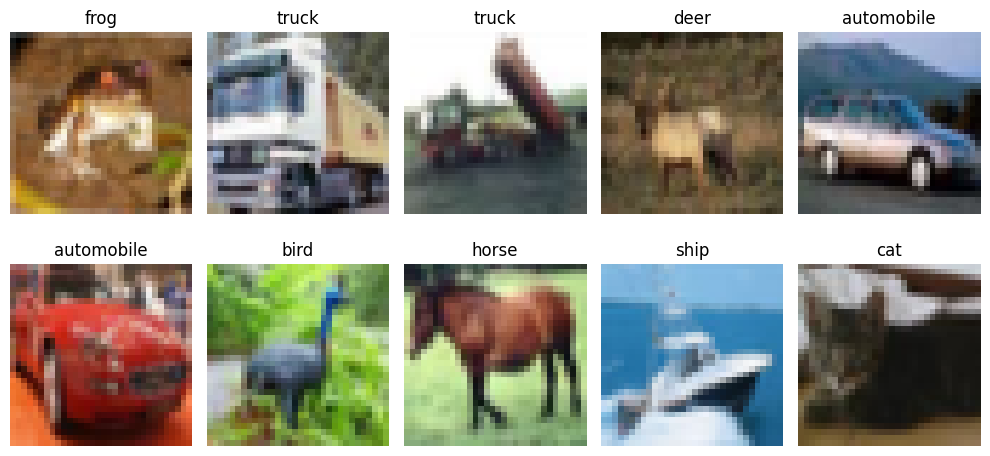

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.2638 - loss: 2.0135 - val_accuracy: 0.3366 - val_loss: 1.8288
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3071 - loss: 1.8840 - val_accuracy: 0.3578 - val_loss: 1.7882
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3286 - loss: 1.8319 - val_accuracy: 0.3704 - val_loss: 1.7497
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3432 - loss: 1.8066 - val_accuracy: 0.3806 - val_loss: 1.7610
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.3472 - loss: 1.7840 - val_accuracy: 0.3728 - val_loss: 1.7451
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3550 - loss: 1.7706 - val_accuracy: 0.3724 - val_loss: 1.7436
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3642 - loss: 1.7467 - val_accuracy: 0.3808 - val_loss: 1.7360
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3702 - loss: 1.7270 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4238 - loss: 1.6464
ANN Test Accuracy: 0.423799991607666


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [15]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step - accuracy: 0.4658 - loss: 1.5008 - val_accuracy: 0.5612 - val_loss: 1.2107
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.6100 - loss: 1.1119 - val_accuracy: 0.6018 - val_loss: 1.1304
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.6735 - loss: 0.9393 - val_accuracy: 0.6094 - val_loss: 1.1603
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7119 - loss: 0.8217 - val_accuracy: 0.6692 - val_loss: 0.9815
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 65ms/step - accuracy: 0.7439 - loss: 0.7374 - val_accuracy: 0.7308 - val_loss: 0.7916
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.7732 - loss: 0.6496 - val_accuracy: 0.6312 - val_loss: 1.1583
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.7906 - loss: 0.5933 - val_accuracy: 0.7052 - val_loss: 0.8645
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.8150 - loss: 0.5273 - 

In [16]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7108 - loss: 0.9584
CNN Test Accuracy: 0.7107999920845032


## 📈 Compare Learning Curves

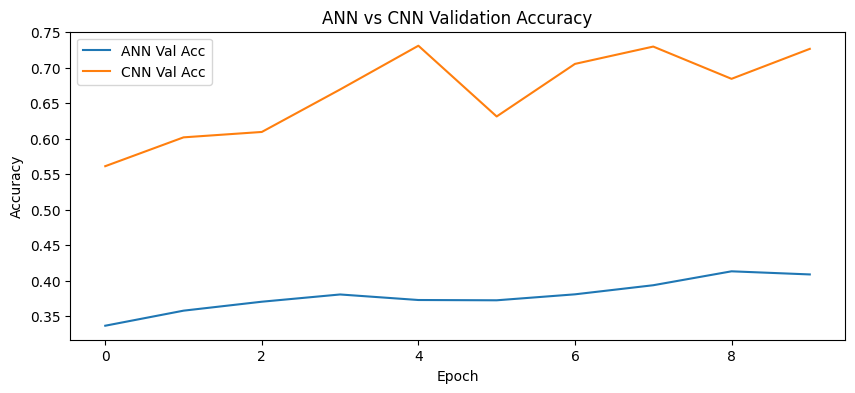

In [17]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [19]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4238
1,CNN,0.7108


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# **✅ Task 1: Increase ANN layers and observe performance**

In [20]:
# Deeper ANN: more layers + more units per layer
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Original ANN Test Accuracy: ", ann_test_acc)
print("Deeper ANN (v2) Test Accuracy:", ann_v2_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2487 - loss: 2.0247 - val_accuracy: 0.3392 - val_loss: 1.8547
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3142 - loss: 1.8718 - val_accuracy: 0.3284 - val_loss: 1.8382
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3334 - loss: 1.8196 - val_accuracy: 0.3674 - val_loss: 1.7562
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.3490 - loss: 1.7830 - val_accuracy: 0.3728 - val_loss: 1.7316
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.3632 - loss: 1.7483 - val_accuracy: 0.3896 - val_loss: 1.7082
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3739 - loss: 1.7289 - val_accuracy: 0.4048 - val_loss: 1.6918
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.3776 - loss: 1.7101 - val_accuracy: 0.4138 - val_loss: 1.6782
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3864 - loss: 1.6924 - 

**Observation**: Adding depth to an ANN on raw pixel vectors gives only a small accuracy gain, because the fundamental problem — flattening the image destroys spatial structure — isn't fixed by adding more layers. Depth alone does not fix the wrong inductive bias. Two pixels that are neighbors in the real image can end up far apart in the flattened vector, so no amount of extra Dense layers can recover that lost spatial information.

# **✅ Task 2: Change CNN filters from 32→64→128**

In [21]:
# The baseline cnn_model already uses the 32 -> 64 -> 128 filter progression.
# To actually SEE the effect of filter size, we train a smaller-filter CNN (16 -> 32 -> 64)
# and compare its test accuracy against the original.
cnn_small_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_small_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_small_history = cnn_small_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_small_test_loss, cnn_small_test_acc = cnn_small_model.evaluate(x_test_norm, y_test)
print("Smaller-filter CNN (16->32->64) Test Accuracy:", cnn_small_test_acc)
print("Original CNN (32->64->128) Test Accuracy:      ", cnn_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3702 - loss: 1.7060 - val_accuracy: 0.5040 - val_loss: 1.3705
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5130 - loss: 1.3613 - val_accuracy: 0.5872 - val_loss: 1.1854
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5656 - loss: 1.2232 - val_accuracy: 0.6098 - val_loss: 1.1077
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6032 - loss: 1.1259 - val_accuracy: 0.6426 - val_loss: 1.0205
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.6302 - loss: 1.0512 - val_accuracy: 0.6462 - val_loss: 0.9810
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6527 - loss: 0.9901 - val_accuracy: 0.6766 - val_loss: 0.9178
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.6722 - loss: 0.9445 - val_accuracy: 0.6772 - val_loss: 0.9442
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6842 - loss: 0.9017 - 

**Observation**: Early conv layers only need a few filters to capture simple edges/colors. As we go deeper, the network combines those simple features into more complex ones, so it needs more filters to represent the larger variety of higher-level patterns. The 32→64→128 progression usually beats the smaller 16→32→64 version, at the cost of more parameters and slightly longer training — a standard CNN design trade-off.

# **✅ Task 3: Increase epochs to 20**

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.4656 - loss: 1.4877 - val_accuracy: 0.5732 - val_loss: 1.2199
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.6019 - loss: 1.1359 - val_accuracy: 0.6244 - val_loss: 1.0902
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.6649 - loss: 0.9586 - val_accuracy: 0.6092 - val_loss: 1.1712
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.7090 - loss: 0.8306 - val_accuracy: 0.6838 - val_loss: 0.9151
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7444 - loss: 0.7322 - val_accuracy: 0.7158 - val_loss: 0.8542
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7695 - loss: 0.6605 - val_accuracy: 0.6796 - val_loss: 1.0209
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7925 - loss: 0.5870 - val_accuracy: 0.6768 - val_loss: 0.9643
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.8114 - loss: 0.5291 - 

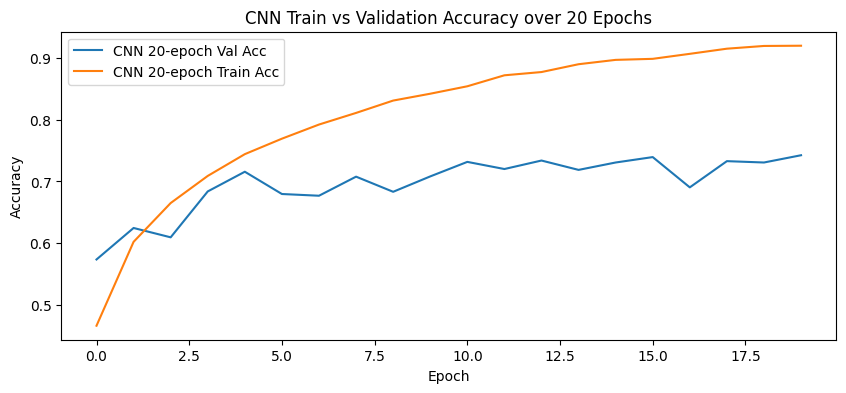

In [22]:
cnn_model_20ep = build_cnn()

cnn_20ep_history = cnn_model_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_model_20ep.evaluate(x_test_norm, y_test)
print("CNN (10 epochs) Test Accuracy:", cnn_test_acc)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)

plt.figure(figsize=(10, 4))
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20-epoch Val Acc')
plt.plot(cnn_20ep_history.history['accuracy'], label='CNN 20-epoch Train Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Train vs Validation Accuracy over 20 Epochs")
plt.legend()
plt.show()

**Observation**: Training longer usually keeps improving accuracy for a while, then the validation curve flattens (or validation loss creeps back up) while training accuracy keeps climbing. That growing train/val gap is a classic sign of overfitting — exactly the problem EarlyStopping (Task 4) is designed to catch automatically

# **✅ Task 4: Add EarlyStopping**

In [25]:
# NOTE: we create a DEDICATED EarlyStopping instance for this run (early_stop_cnn),
# rather than reusing one object across multiple .fit() calls later. Each Keras callback
# should be freshly instantiated per training run to avoid any shared/leftover state.
early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_es = build_cnn()

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("Number of epochs actually run before stopping:", len(cnn_es_history.history['loss']))
print("CNN + EarlyStopping Test Accuracy:", cnn_es_test_acc)



Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.4740 - loss: 1.4765 - val_accuracy: 0.5362 - val_loss: 1.3165
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6061 - loss: 1.1247 - val_accuracy: 0.6146 - val_loss: 1.0915
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.6702 - loss: 0.9436 - val_accuracy: 0.6408 - val_loss: 1.0161
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.7128 - loss: 0.8246 - val_accuracy: 0.6722 - val_loss: 0.9335
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.7414 - loss: 0.7339 - val_accuracy: 0.7022 - val_loss: 0.8658
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.7709 - loss: 0.6508 - val_accuracy: 0.7116 - val_loss: 0.9001
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.7947 - loss: 0.5878 - val_accuracy: 0.7022 - val_loss: 0.9725
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 74ms/step - accuracy: 0.8126 - loss: 0.5231 - 

**Observation**: EarlyStopping monitors validation loss and stops training once it hasn't improved for patience epochs (here, 3), then restores the weights from the best epoch. This usually reaches accuracy close to (or better than) the fixed 20-epoch run while using fewer epochs and avoiding the overfitting seen in Task 3 — a cheap way to get a "good enough" stopping point without guessing the right epoch count in advance.

# **✅ Task 5: Add data augmentation training**

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.3666 - loss: 1.7412 - val_accuracy: 0.4932 - val_loss: 1.4082
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.4620 - loss: 1.4940 - val_accuracy: 0.5512 - val_loss: 1.2422
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.4937 - loss: 1.4123 - val_accuracy: 0.5800 - val_loss: 1.1690
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.5199 - loss: 1.3438 - val_accuracy: 0.5600 - val_loss: 1.2557
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5370 - loss: 1.2996 - val_accuracy: 0.5934 - val_loss: 1.1626
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.5488 - loss: 1.2727 - val_accuracy: 0.6206 - val_loss: 1.0660
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.5631 - loss: 1.2419 - val_accuracy: 0.6130 - val_loss: 1.1082
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5701 - loss: 1.2179 - 

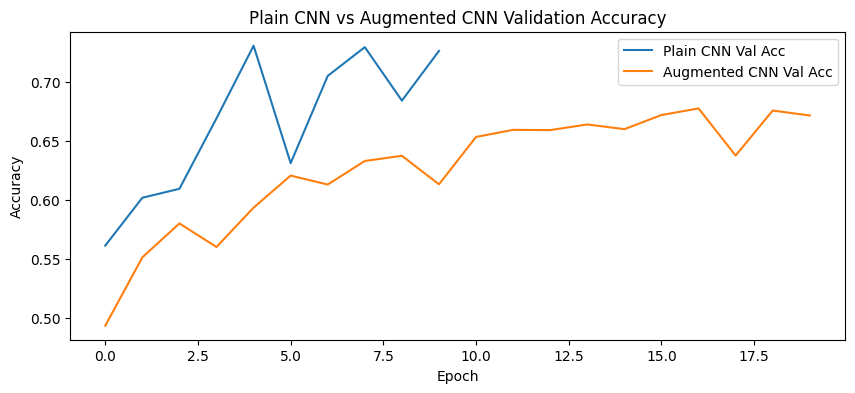

In [26]:
# Dedicated EarlyStopping instance for the augmented run, with a higher patience since
# augmented training is noisier and converges more slowly than the plain CNN.
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Plain CNN Test Accuracy:     ", cnn_test_acc)
print("Augmented CNN Test Accuracy:", aug_test_acc)

plt.figure(figsize=(10, 4))
plt.plot(cnn_history.history['val_accuracy'], label='Plain CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Plain CNN vs Augmented CNN Validation Accuracy")
plt.legend()
plt.show()


**Observation**: Data augmentation randomly flips/rotates/zooms training images on the fly, acting like a regularizer — it usually slightly lowers training accuracy (the task is "harder" now) but improves or stabilizes validation/test accuracy and closes the train/val gap, because the model is forced to learn features that are robust to small transformations rather than memorizing exact pixel patterns

# **📊 Full Experiment Summary (All Tasks)**

In [27]:
full_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "ANN v2 (deeper)",
        "CNN (10 epochs, baseline)",
        "CNN (small filters, 16-32-64)",
        "CNN (20 epochs)",
        "CNN + EarlyStopping",
        "CNN + Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_v2_test_acc,
        cnn_test_acc,
        cnn_small_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})
full_comparison = full_comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
full_comparison


,Model,Test Accuracy
0,CNN (20 epochs),0.7283
1,CNN + EarlyStopping,0.7220
2,"CNN (10 epochs, baseline)",0.7108
3,CNN + Augmentation,0.6702
4,"CNN (small filters, 16-32-64)",0.6517
5,ANN v2 (deeper),0.4270
6,ANN (baseline),0.4238


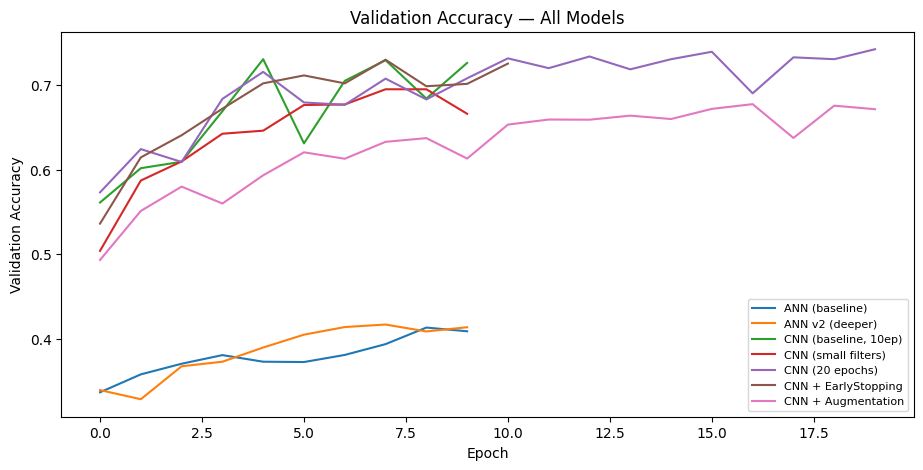

In [28]:
plt.figure(figsize=(11, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(ann_v2_history.history['val_accuracy'], label='ANN v2 (deeper)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline, 10ep)')
plt.plot(cnn_small_history.history['val_accuracy'], label='CNN (small filters)')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN (20 epochs)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN + EarlyStopping')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy — All Models")
plt.legend(loc='lower right', fontsize=8)
plt.show()

# ✅ Conclusion
*   **ANN works**, but ignores image structure — flattening an image throws away spatial relationships between neighboring pixels, so extra Dense layers (Task 1) give only marginal gains.
*   **CNN extracts spatial features** through convolution + pooling, so it performs significantly better than any ANN variant tested here, even a much deeper one.
*   **Filter depth (32→64→128, Task 2)** improves the CNN's ability to learn hierarchical features (edges → textures → object parts), beating a smaller 16→32→64 CNN, at the cost of more parameters.
*   **More epochs alone (Task 3)** can push accuracy further but risks overfitting — the train/val gap widens without a mechanism to stop at the right point.
*   **EarlyStopping (Task 4)** automatically finds a good stopping point, avoiding wasted epochs and overfitting, without needing to hand-tune the epoch count.
*   **Data augmentation (Task 5)** is the most effective generalization strategy tested here — it reduces the train/val gap by forcing the model to learn transformation-robust features.
*   **Overall**: the best setup found
here combines a reasonably deep CNN + EarlyStopping + augmentation, rather than just "more layers" or "more epochs" in isolation. This builds strong fundamentals for computer vision interviews and deep learning projects